<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 35px;">Time Series analysis of futures prices on commodities</h1>
  </div>
  <div style="padding: 1em;">
  <p>

**📖 Background**

Time series analysis of financial data is one of the cornerstones of financial engineering, where we need to assess predictive stochastic models for market and credit risk drivers in order to be able to forecast future portfolio’s return. In addition, cointegration is a crucial tool to deal with fitting and forecasting of multivariate time series and it is at the foundation of well known trading signals for assessing optimal portfolio strategies.


**📌 Objective**

This practical project is designed to give you hands-on experience in financial time series analysis to analyze oil-related data. You will familiarize with model selection, fit and forecast of the main stochastic models encountered during the course, and you will be asked to qualitatively evaluate different model choices for the same time series. Moreover, you will learn the importance of correctly assess cointegration in the data.

**📂 Data**

- Estimation data: Weekly prices of crude oil WTI futures (yahoo finance ticker: 'CL=F') and crude oil BRENT futures (yahoo finance ticker: 'BZ=F'). The two futures track crude oil extraction from different places. Weekly stock prices of NVIDIA (yahoo finance ticker: 'NVDA'). All time series run from 1 Jan 2013 to 1 Jan 2023.
- Forecasting data: Last 10 observations of weekly prices of Crude Oil WTI futures from 05 Mar 2025.

</p></div></div>

<h1 style="font-weight: bold; font-size:14px; line-height:1.5em;">🛠 Prepare environment</h1>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from yfinance import download

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA

<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">📝 Task 1: Data exploration</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Download the datasets of weekly prices of oil WRT futures and crute oil BRENT futures; and the weekly stock prices of NVIDIA.
- Convert the time series into log-prices.
- Plot the time series of log-prices, log-prices differences, absolute value of log-differences.
- Briefly comment on the plots. Do the log-prices look stationary? Do the log-prices differences look stationary? Support quantitatively your intuition by fitting AR(1) models on each of the time series and comment on the parameters $b$ obtained.
- Do you think it would be correct assuming the log-prices differences are independent across time?
- Comment on the empirical phenomenon observed (trend, mean reversion, volatility clustering, etc.).

</p></div></div>

In [ ]:
# -----------------------------
# Settings
# -----------------------------
START = "2013-01-01"
END   = "2023-01-01"
TICKERS = {"WTI": "CL=F", "BRENT": "BZ=F", "NVDA": "NVDA"}

def download_weekly_close(tickers, start=START, end=END, weekday="FRI"):
    """
    Downloads daily data and resamples to weekly closes (last business day of the week).
    Using daily->weekly avoids quirks of interval='1wk' for some tickers.
    """
    df = download(list(tickers.values()), start=start, end=end, auto_adjust=False, progress=False)
    # Prefer Adj Close if available; fallback to Close
    px = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]
    px = px.rename(columns={v: k for k, v in tickers.items()})

    # Weekly (end of week). Use W-FRI to represent "weekly close" aligned to Friday.
    px_w = px.resample(f"W-{weekday}").last()
    px_w = px_w.dropna(how="all")
    return px_w

px_w = download_weekly_close(TICKERS, START, END)
px_w.tail()

Ticker,BRENT,WTI,NVDA
Date,,,
2022-12-02,85.570000,79.980003,16.859123
2022-12-09,76.099998,71.019997,16.983997
2022-12-16,79.040001,74.290001,16.554428
2022-12-23,83.919998,79.559998,15.190793
2022-12-30,85.910004,80.260002,14.599387


In [ ]:
logp = np.log(px_w)
dlogp = logp.diff()          # log-price differences (approx returns)
abs_dlogp = dlogp.abs()

# Optional: drop first NaN row after diff
dlogp = dlogp.dropna()
abs_dlogp = abs_dlogp.dropna()

logp.describe()

Ticker,BRENT,WTI,NVDA
count,522.000000,522.000000,522.000000
mean,4.206029,4.127337,1.022394
std,0.346385,0.351793,1.452006
min,3.065258,2.829678,-1.270303
25%,3.953405,3.884395,-0.622329
50%,4.179375,4.086648,1.382228
75%,4.511559,4.448426,2.250336
max,4.804103,4.793060,3.493996


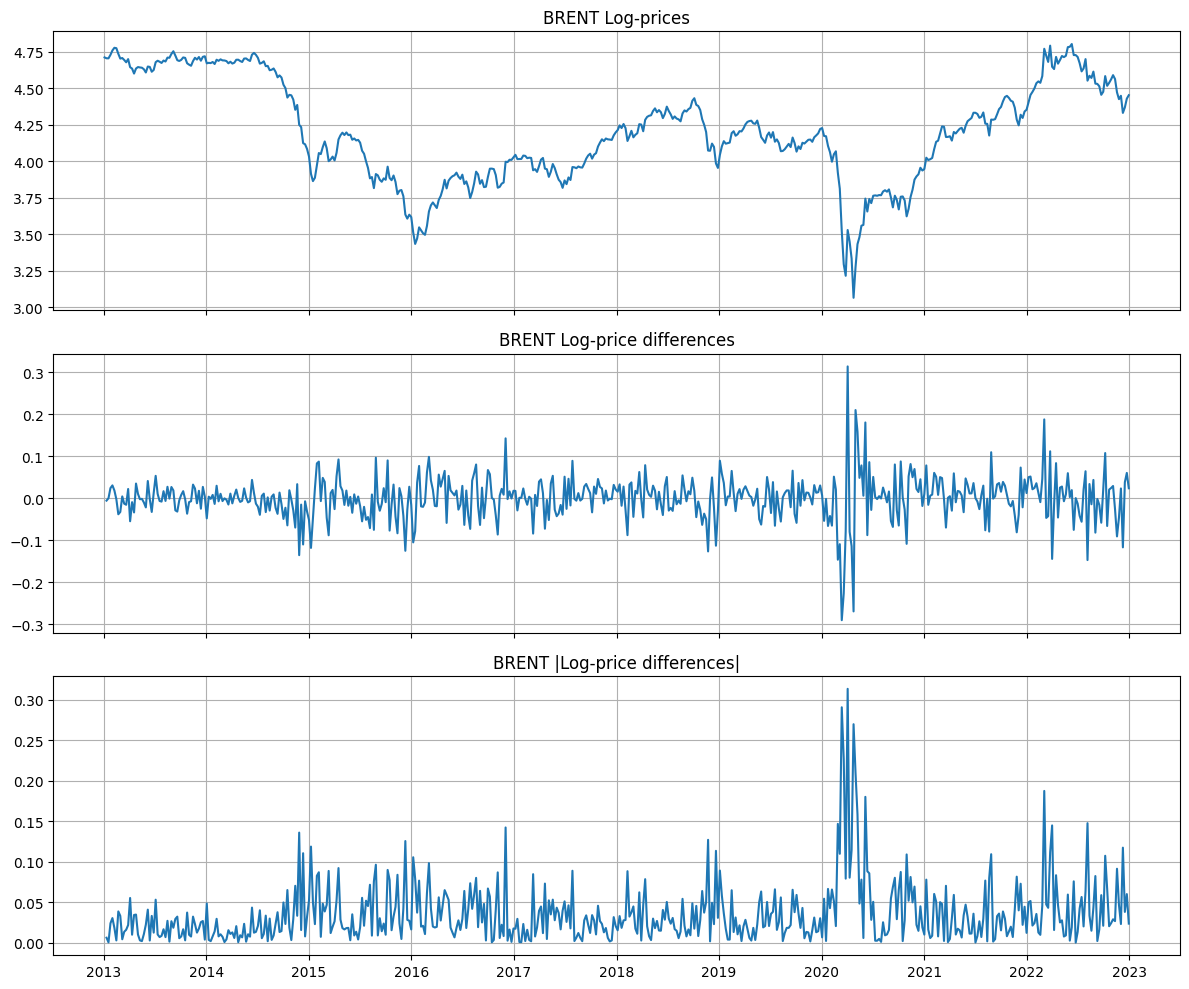

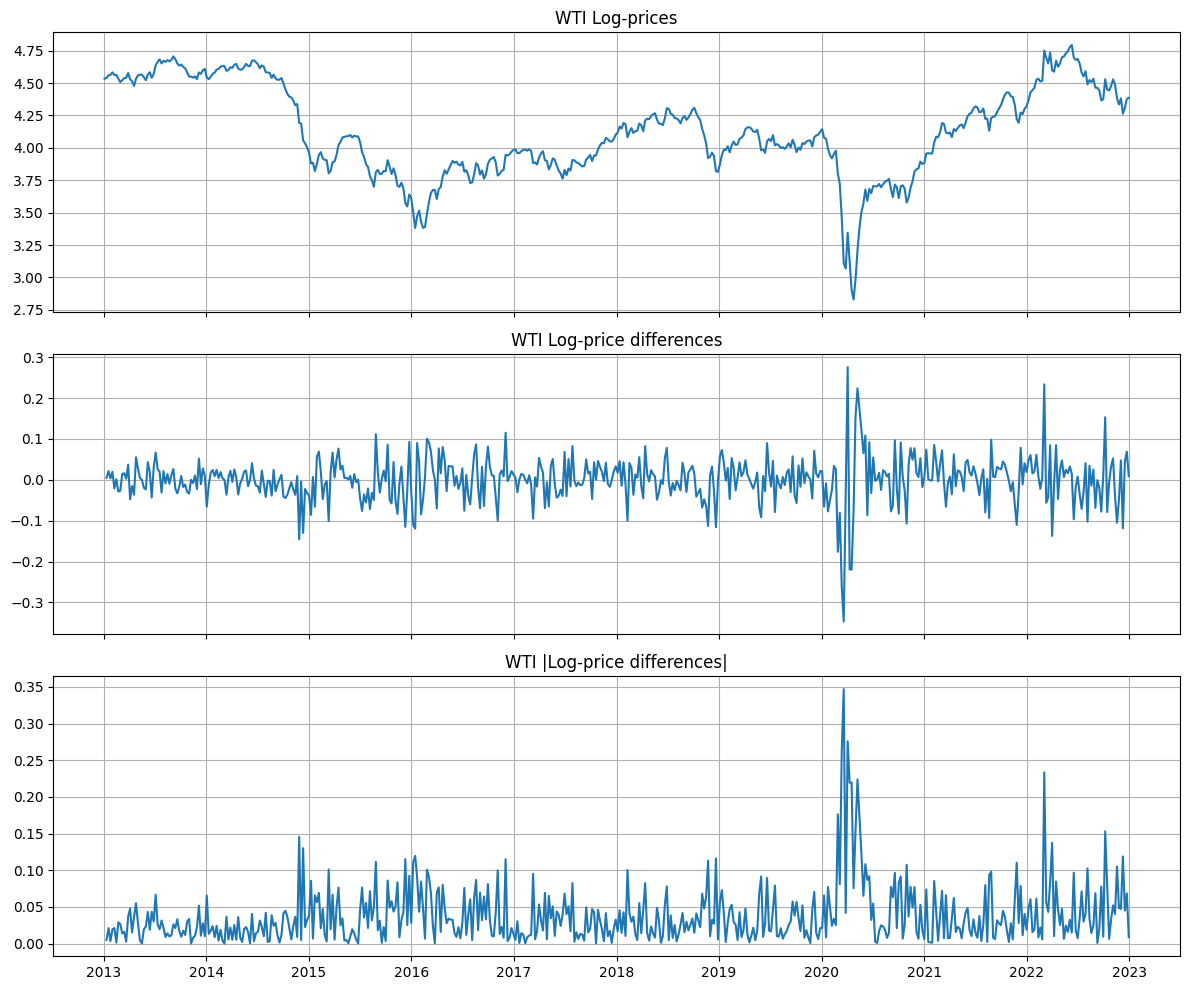

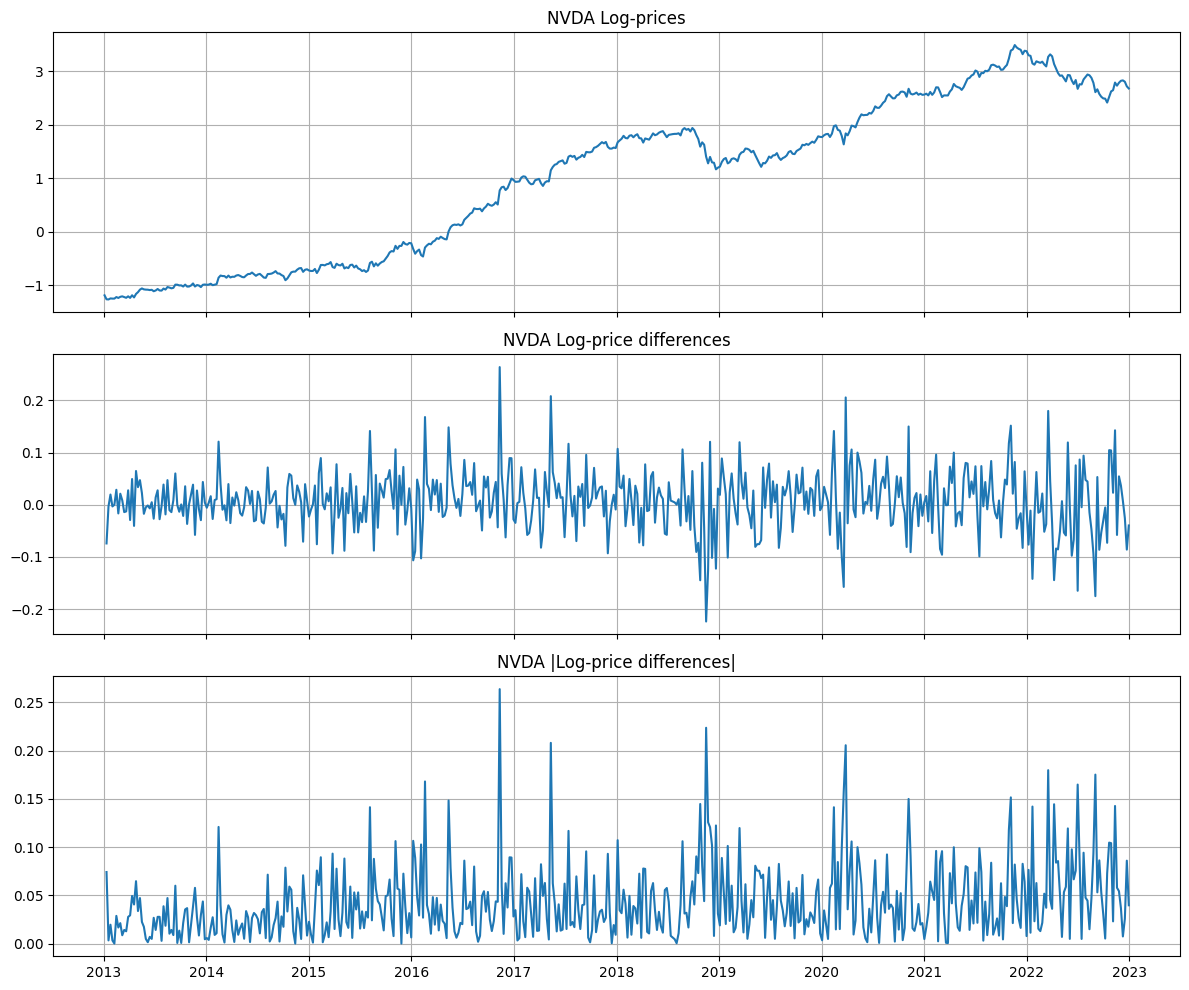

In [ ]:
def plot_bundle(logp, dlogp, abs_dlogp, title_prefix=""):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(logp.index, logp.values)
    axes[0].set_title(f"{title_prefix} Log-prices")
    axes[0].grid(True)

    axes[1].plot(dlogp.index, dlogp.values)
    axes[1].set_title(f"{title_prefix} Log-price differences")
    axes[1].grid(True)

    axes[2].plot(abs_dlogp.index, abs_dlogp.values)
    axes[2].set_title(f"{title_prefix} |Log-price differences|")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

for col in logp.columns:
    plot_bundle(logp[col].dropna(), dlogp[col].dropna(), abs_dlogp[col].dropna(), title_prefix=col)

In [ ]:
def fit_ar1(series: pd.Series):
    series = series.dropna()
    model = AutoReg(series, lags=1, old_names=False).fit()
    params = model.params
    # params usually: const and L1 coefficient
    out = {
        "n": int(model.nobs),
        "const": float(params.get("const", np.nan)),
        "b (lag1)": float(params.iloc[1]) if len(params) > 1 else np.nan,
        "b_pvalue": float(model.pvalues.iloc[1]) if len(model.pvalues) > 1 else np.nan,
        "AIC": float(model.aic),
        "BIC": float(model.bic),
    }
    return out

rows = []
for col in logp.columns:
    rows.append({"series": col, "type": "log-price", **fit_ar1(logp[col])})
    rows.append({"series": col, "type": "log-diff",  **fit_ar1(dlogp[col])})

ar1_table = pd.DataFrame(rows)
ar1_table

,series,type,n,const,b (lag1),b_pvalue,AIC,BIC
0,BRENT,log-price,521,0.053516,0.987157,0.000000,-1600.060674,-1587.293424
1,BRENT,log-diff,520,-0.000440,0.084875,0.052128,-1595.931537,-1583.170051
2,WTI,log-price,521,0.054404,0.986748,0.000000,-1530.769626,-1518.002376
3,WTI,log-diff,520,-0.000247,0.159673,0.000226,-1536.589398,-1523.827911
4,NVDA,log-price,521,0.009217,0.998252,0.000000,-1508.835923,-1496.068672
5,NVDA,log-diff,520,0.007222,0.049245,0.260238,-1507.234283,-1494.472796


In [ ]:
def independence_diagnostics(x: pd.Series, lags=10):
    x = x.dropna()
    lb_ret = acorr_ljungbox(x, lags=[lags], return_df=True)      # autocorr in mean
    lb_abs = acorr_ljungbox(x.abs(), lags=[lags], return_df=True) # autocorr in magnitude
    arch = het_arch(x)  # Engle ARCH test (LM) on heteroskedasticity
    return {
        "LB_pvalue_returns": float(lb_ret["lb_pvalue"].iloc[0]),
        "LB_pvalue_abs": float(lb_abs["lb_pvalue"].iloc[0]),
        "ARCH_LM_pvalue": float(arch[1]),
    }

diag_rows = []
for col in dlogp.columns:
    diag_rows.append({"series": col, **independence_diagnostics(dlogp[col], lags=10)})

diag_table = pd.DataFrame(diag_rows)
diag_table

,series,LB_pvalue_returns,LB_pvalue_abs,ARCH_LM_pvalue
0,BRENT,0.013679,1.265768e-75,4.735683e-33
1,WTI,0.001051,5.487144e-80,5.030272e-32
2,NVDA,0.954486,1.366613e-07,4.422050e-02


In [ ]:
def adf_test(x: pd.Series):
    x = x.dropna()
    stat, pval, *_ = adfuller(x, autolag="AIC")
    return stat, pval

def kpss_test(x: pd.Series, regression="c"):
    x = x.dropna()
    stat, pval, *_ = kpss(x, regression=regression, nlags="auto")
    return stat, pval

tests = []
for col in logp.columns:
    adf_lp = adf_test(logp[col])
    adf_dl = adf_test(dlogp[col])
    kpss_lp = kpss_test(logp[col], regression="c")
    kpss_dl = kpss_test(dlogp[col], regression="c")
    tests.append({
        "series": col,
        "ADF p (logp)": adf_lp[1],
        "ADF p (dlogp)": adf_dl[1],
        "KPSS p (logp)": kpss_lp[1],
        "KPSS p (dlogp)": kpss_dl[1],
    })

pd.DataFrame(tests)

/tmp/ipython-input-3815185106.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(x, regression=regression, nlags="auto")
/tmp/ipython-input-3815185106.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(x, regression=regression, nlags="auto")
/tmp/ipython-input-3815185106.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, *_ = kpss(x, regression=regression, nlags="auto")
/tmp/ipython-input-3815185106.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returne

,series,ADF p (logp),ADF p (dlogp),KPSS p (logp),KPSS p (dlogp)
0,BRENT,0.148510,1.564442e-14,0.041226,0.1
1,WTI,0.140968,2.081207e-22,0.043598,0.1
2,NVDA,0.745493,0.000000e+00,0.010000,0.1


<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
  <i>The log-price series of WTI, Brent and NVDA display clear level shifts and long persistent movements, suggesting non-stationarity. This is supported quantitatively by AR(1) fits on log-prices (lag-1 coefficient close to 1 for all series) and by stationarity tests: ADF fails to reject a unit root in log-prices while KPSS rejects stationarity. Conversely, log-price differences appear approximately stationary: ADF strongly rejects a unit root and KPSS does not reject stationarity.
Independence of log-price differences is not a reasonable assumption. While linear autocorrelation in returns is weak overall (especially for NVDA), Ljung–Box and ARCH tests show strong dependence in the second moment: absolute returns are highly autocorrelated and ARCH effects are significant, indicating volatility clustering and conditional heteroskedasticity. Overall, the data exhibit non-stationary levels, near-stationary differences, and pronounced volatility clustering with extreme events (notably around 2020).</i>
</div>

<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">📝 Task 2: Model fit</h1>
  </div>
  <div style="padding: 1em;">
  <p>
      
- Based on the assessment done at the previous step, fit each marginal time series with the proper model, motivating your choices.
- Extract realizations of the driving white noises and their absolute value and plot them. Comment on the obtained results.
- Compute time-conditioning flexible probabilities with proper selected half-life parameter, for the joint scenarios.

</p></div></div>

In [ ]:
def fit_ar_orders(x: pd.Series, p_max=3, lb_lags=10):
    x = x.dropna()
    out = []
    for p in range(p_max + 1):
        # AR(p) on returns: ARIMA(p,0,0) with constant mean
        res = ARIMA(x, order=(p, 0, 0), trend="c").fit()
        resid = res.resid.dropna()
        lb_p = acorr_ljungbox(resid, lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
        out.append({
            "p": p,
            "AIC": res.aic,
            "BIC": res.bic,
            "LB_pvalue_resid": float(lb_p),
        })
    return pd.DataFrame(out).sort_values("AIC")

# Esempio: per WTI returns
fit_ar_orders(dlogp["WTI"], p_max=3, lb_lags=10)

,p,AIC,BIC,LB_pvalue_resid
3,3,-1542.340081,-1521.061331,0.398829
2,2,-1541.699429,-1524.676429,0.238434
1,1,-1540.521869,-1527.754619,0.118712
0,0,-1529.092771,-1520.581271,0.001051


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def fit_ar_orders(x: pd.Series, p_max=3, lb_lags=10):
    x = x.dropna()
    out = []
    for p in range(p_max + 1):
        res = ARIMA(x, order=(p, 0, 0), trend="c").fit()
        resid = res.resid.dropna()
        lb_p = acorr_ljungbox(resid, lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
        out.append({
            "p": p,
            "AIC": res.aic,
            "BIC": res.bic,
            "LB_pvalue_resid": float(lb_p),
        })
    return pd.DataFrame(out).sort_values("BIC")  # BIC: più parsimonioso

def choose_p_bic_with_lb(table: pd.DataFrame, lb_threshold=0.05):
    """
    Regola: tra i modelli con residui 'ok' (LB pval > soglia), prendi quello con BIC minimo.
    Se nessuno passa, prendi comunque BIC minimo (e lo segnali).
    """
    ok = table[table["LB_pvalue_resid"] > lb_threshold]
    if len(ok) > 0:
        return int(ok.iloc[0]["p"]), True
    return int(table.iloc[0]["p"]), False

def fit_final_ar(x: pd.Series, p: int):
    x = x.dropna()
    res = ARIMA(x, order=(p, 0, 0), trend="c").fit()
    return res

In [ ]:
# assumo che tu abbia già dlogp = logp.diff().dropna() dalla Task 1
series_list = ["WTI", "BRENT", "NVDA"]

selection = {}
results = {}
tables = {}

for s in series_list:
    tab = fit_ar_orders(dlogp[s], p_max=3, lb_lags=10)
    p_star, passed = choose_p_bic_with_lb(tab, lb_threshold=0.05)
    tables[s] = tab
    selection[s] = {"p_star": p_star, "LB_passed": passed}
    results[s] = fit_final_ar(dlogp[s], p_star)

selection, tables["WTI"]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


({'WTI': {'p_star': 1, 'LB_passed': True},
  'BRENT': {'p_star': 1, 'LB_passed': True},
  'NVDA': {'p_star': 0, 'LB_passed': True}},
    p          AIC          BIC  LB_pvalue_resid
 1  1 -1540.521869 -1527.754619         0.118712
 2  2 -1541.699429 -1524.676429         0.238434
 3  3 -1542.340081 -1521.061331         0.398829
 0  0 -1529.092771 -1520.581271         0.001051)

In [ ]:
eps = pd.DataFrame(index=dlogp.index, columns=series_list, dtype=float)

diag = []
for s in series_list:
    res = results[s]
    # innovazioni ~ residui del modello sui returns
    e = res.resid.reindex(dlogp.index)
    eps[s] = e

    # diagnostics: autocorr mean (resid), autocorr magnitude (|resid|), ARCH
    lb_ret = acorr_ljungbox(e.dropna(), lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    lb_abs = acorr_ljungbox(e.dropna().abs(), lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    arch_p = het_arch(e.dropna())[1]

    diag.append({
        "series": s,
        "chosen_p": selection[s]["p_star"],
        "LB_pvalue_resid": float(lb_ret),
        "LB_pvalue_abs_resid": float(lb_abs),
        "ARCH_LM_pvalue": float(arch_p),
    })

diag_table = pd.DataFrame(diag)
diag_table

,series,chosen_p,LB_pvalue_resid,LB_pvalue_abs_resid,ARCH_LM_pvalue
0,WTI,1,0.118712,4.241782e-59,7.422466e-33
1,BRENT,1,0.058103,1.032181e-70,4.605138e-32
2,NVDA,0,0.954486,1.054693e-09,6.829981e-03


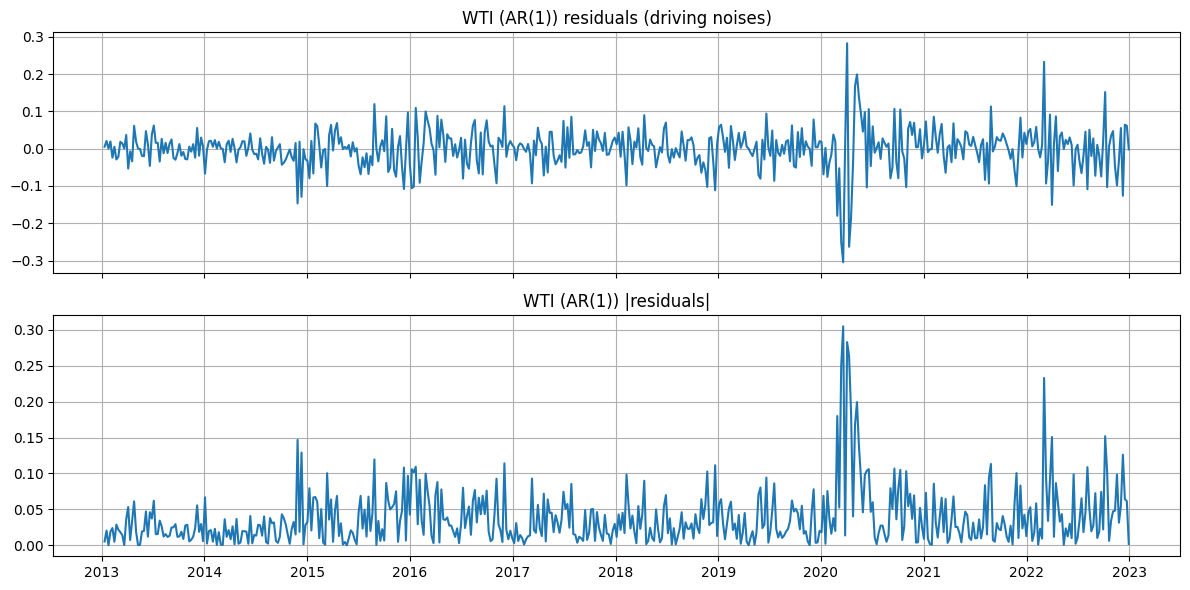

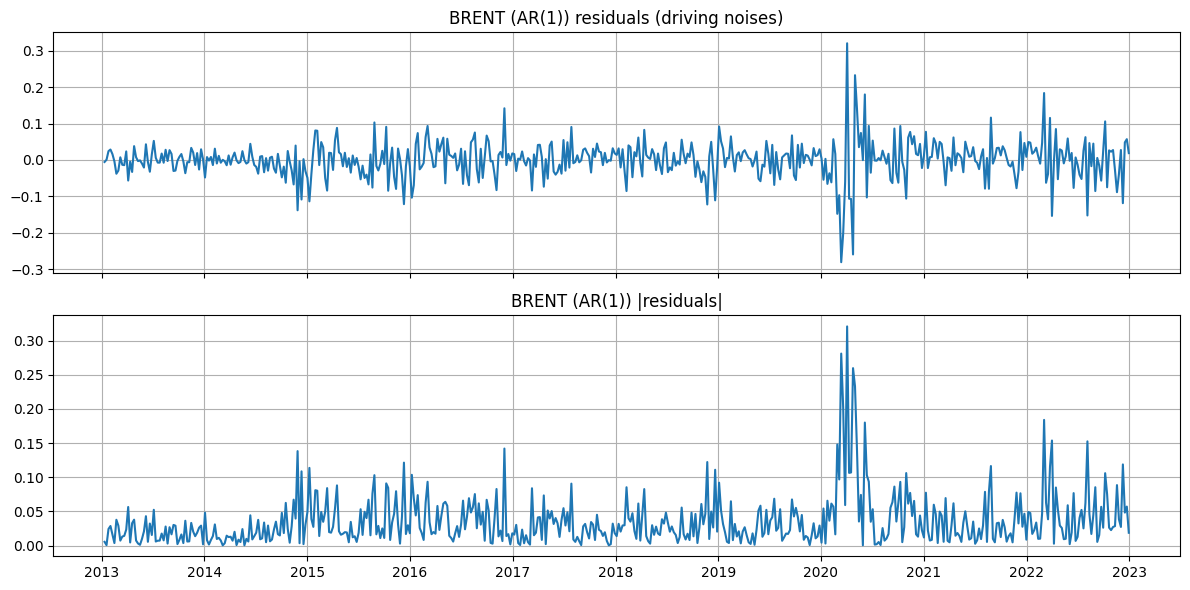

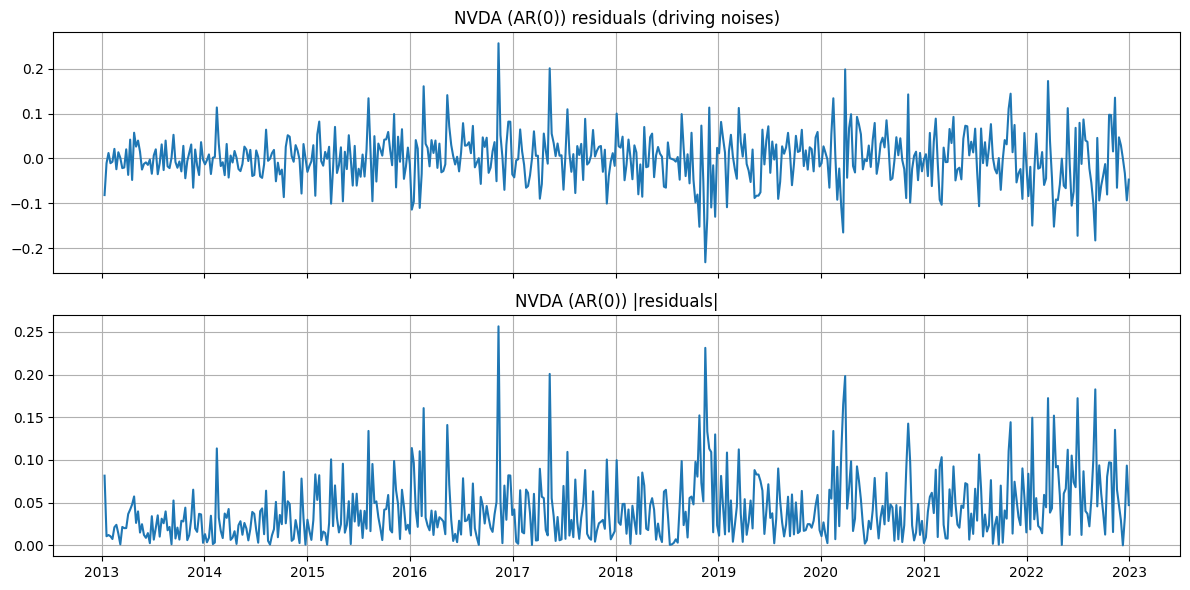

In [ ]:
def plot_residuals(eps: pd.Series, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(eps.index, eps.values)
    axes[0].set_title(f"{title} residuals (driving noises)")
    axes[0].grid(True)

    axes[1].plot(eps.index, np.abs(eps.values))
    axes[1].set_title(f"{title} |residuals|")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

for s in series_list:
    plot_residuals(eps[s].dropna(), title=f"{s} (AR({selection[s]['p_star']}))")

In [ ]:
def exp_half_life_weights(index: pd.DatetimeIndex, half_life: int):
    """
    half_life: numero di periodi (settimane) dopo cui il peso si dimezza.
    """
    T = len(index)
    ages = np.arange(T-1, -1, -1)  # last obs age=0, first obs age=T-1
    w = 0.5 ** (ages / half_life)
    w = w / w.sum()
    return pd.Series(w, index=index, name="w")

def effective_sample_size(w: np.ndarray):
    w = np.asarray(w)
    return 1.0 / np.sum(w**2)

# grid candidati (settimane): 13=~3m, 26=~6m, 52=~1y, 78=~1.5y, 104=~2y, 156=~3y
half_life_grid = [13, 26, 52, 78, 104, 156]
ess_table = []

for h in half_life_grid:
    w = exp_half_life_weights(eps.dropna().index, h).values
    ess_table.append({"half_life_weeks": h, "ESS": effective_sample_size(w)})

ess_table = pd.DataFrame(ess_table).sort_values("half_life_weeks")
ess_table

,half_life_weeks,ESS
0,13,37.518957
1,26,75.024446
2,52,149.753613
3,78,220.712906
4,104,282.012083
5,156,369.195425


In [ ]:
def choose_half_life_by_target_ess(index, target_ess=150, grid=[13,26,52,78,104,156]):
    best = None
    for h in grid:
        w = exp_half_life_weights(index, h).values
        ess = effective_sample_size(w)
        score = abs(ess - target_ess)
        if (best is None) or (score < best["score"]):
            best = {"half_life": h, "ESS": ess, "score": score}
    return best

best_h = choose_half_life_by_target_ess(eps.dropna().index, target_ess=150, grid=half_life_grid)
best_h

{'half_life': 52,
 'ESS': np.float64(149.75361287664722),
 'score': np.float64(0.24638712335277546)}

In [ ]:
# scegli half-life (puoi usare best_h["half_life"] o fissare ad es. 104 se vuoi 2 anni)
half_life = int(best_h["half_life"])
w = exp_half_life_weights(eps.dropna().index, half_life)

# joint scenarios: matrice T x 3 delle innovazioni
eps_joint = eps.dropna().copy()

# (opzionale) weighted mean/cov of joint innovations (utile per check)
w_np = w.values.reshape(-1, 1)
mu_w = (w_np * eps_joint.values).sum(axis=0)
Xc = eps_joint.values - mu_w
cov_w = (w_np * Xc).T @ Xc  # già normalizzato perché sum(w)=1

mu_w, cov_w

(array([ 0.0013903 ,  0.00179402, -0.00664333]),
 array([[0.00422694, 0.00367424, 0.00047903],
        [0.00367424, 0.00367686, 0.00051981],
        [0.00047903, 0.00051981, 0.00477804]]))

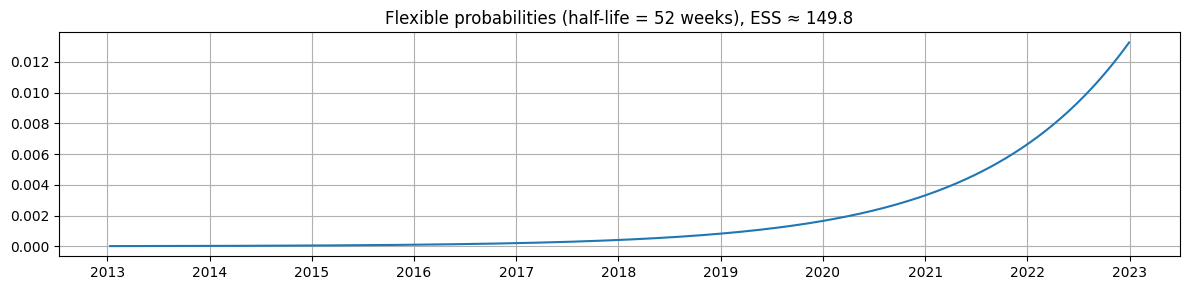

In [ ]:
plt.figure(figsize=(12,3))
plt.plot(w.index, w.values)
plt.title(f"Flexible probabilities (half-life = {half_life} weeks), ESS ≈ {effective_sample_size(w.values):.1f}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
res.mle_retvals.get("converged", None)

True

<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
  <i>Based on stationarity diagnostics, we model weekly log-price differences. We select an AR specification for each marginal series using information criteria and residual diagnostics: WTI and Brent are fit with AR(1), while NVDA is adequately described by a white-noise-in-mean model AR(0). The extracted residuals represent the driving shocks; Ljung–Box tests indicate no remaining linear autocorrelation in residuals, while absolute residuals and ARCH tests reveal strong volatility clustering. To account for time-varying dynamics, we compute time-conditioning flexible probabilities via exponential decay, selecting a half-life of 52 weeks (ESS ≈ 150) and assign these probabilities to the joint residual scenarios for use in weighted bootstrap forecasting.</i>
</div>

<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">📝 Task 3: Forecasting</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Using bootstrapping, compute the scenario-probability forecast of crude oil WTI futures log-price, based on the first 20 observations of weekly prices from 5 Mar 2025 and backwards, over an horizon of 20 weeks. Use 10000 scenarios.
- Display the marginal scenario-probability distribution at the horizon.
- Display the evolution of the marginal scenario-probability expectation and variance forecasts as the horizon spans from 5 Mar 2025 to 20 weeks afterwards for both log-prices and log-prices differences.
- Comment on whether the forecast results match the empirical phenomena discussed in the previous steps.

**Hint:** See <a style="color:#3c9591" href="../Python/1. Theory/Data Science/49. Probabilistic stochastic models/s_projection_stock_bootstrap.ipynb">s_projection_stock_bootstrap</a> for reference.

</p></div></div>

In [ ]:
import pandas as pd
import numpy as np
from yfinance import download

t0 = pd.Timestamp("2025-03-05")  # forecast origin
start_lookback = "2024-06-01"    # abbastanza indietro per avere >=20 settimane

wti_daily = download("CL=F", start=start_lookback, end=(t0 + pd.Timedelta(days=2)).strftime("%Y-%m-%d"))["Close"].dropna()

# weekly aligned to Wednesday (t0 è mercoledì). Se preferisci, usa 'W-FRI' e cambia t0.
wti_weekly = wti_daily.resample("W-WED").last().dropna()

# prendi le 20 osservazioni fino a t0 incluso
wti_20 = wti_weekly.loc[:t0].tail(20)
assert len(wti_20) == 20, f"Ne ho trovate {len(wti_20)}; allarga start_lookback"

x0 = np.log(wti_20.iloc[-1])                    # log-price al tempo 0
r_hist_20 = np.diff(np.log(wti_20.values))      # 19 returns nella finestra

/tmp/ipython-input-3471983911.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wti_daily = download("CL=F", start=start_lookback, end=(t0 + pd.Timedelta(days=2)).strftime("%Y-%m-%d"))["Close"].dropna()
[*********************100%***********************]  1 of 1 completed


In [ ]:
def extract_ar_params(arima_res):
    params = arima_res.params
    # const
    c = params.get("const", params.get("intercept", 0.0))
    # AR coeffs
    ar_keys = [k for k in params.index if str(k).startswith("ar.L")]
    ar_keys = sorted(ar_keys, key=lambda s: int(str(s).split("L")[1]))
    phi = np.array([params[k] for k in ar_keys], dtype=float)
    p = len(phi)
    return float(c), phi, p

c, phi, p = extract_ar_params(results["WTI"])
print("WTI AR order p =", p, "const =", c, "phi =", phi)

WTI AR order p = 1 const = -0.0002845567731898144 phi = [0.15967241]


In [ ]:
# ultimi p returns: [r_t0, r_{t0-1}, ..., r_{t0-p+1}]
r_init = r_hist_20[-p:][::-1].copy()
print("r_init (most recent first):", r_init)

r_init (most recent first): []


In [ ]:
eps_wti = eps["WTI"].dropna().copy()

# pesi time-decay già calcolati (half-life=52) -> riallinea
w_time = w.reindex(eps_wti.index).dropna()
eps_wti = eps_wti.reindex(w_time.index)

# opzionale: centra il pool rispetto ai pesi (evita drift spurio sotto pesatura)
eps_wti_centered = eps_wti - np.sum(w_time.values * eps_wti.values)

In [ ]:
def get_weekly_state(tickers, start, end, anchor="W-WED"):
    df = download(tickers, start=start, end=end)["Close"].dropna(how="all")
    if isinstance(df, pd.Series):
        df = df.to_frame()
    df = df.resample(anchor).last().dropna(how="all")
    return df

use_macro = True
state_tickers = ["^VIX", "DX-Y.NYB", "^TNX"]

if use_macro:
    # stato nel periodo storico (deve coprire eps_wti.index)
    state_hist = get_weekly_state(state_tickers, start="2012-12-01", end="2023-01-10", anchor="W-WED")
    state_hist = state_hist.reindex(eps_wti.index, method="ffill").dropna()

    # stato al tempo t0 (serve fino al 2025)
    state_full = get_weekly_state(state_tickers, start="2012-12-01", end=(t0 + pd.Timedelta(days=2)).strftime("%Y-%m-%d"), anchor="W-WED")
    z0 = state_full.reindex([t0], method="ffill").iloc[0]

    # allinea tutto su index comune
    idx_common = eps_wti.index.intersection(state_hist.index)
    eps_pool = eps_wti_centered.reindex(idx_common)
    w_base = w_time.reindex(idx_common)
    Z = state_hist.reindex(idx_common)

    # standardizza (anche weighted: elegante e coerente)
    W = w_base.values.reshape(-1, 1)
    muZ = (W * Z.values).sum(axis=0)
    sigZ = np.sqrt((W * (Z.values - muZ)**2).sum(axis=0))
    Zs = (Z.values - muZ) / sigZ
    z0s = (z0.values - muZ) / sigZ

    # kernel weights: exp(-dist^2/(2*bw^2))
    def kernel_weights(Zs, z0s, bw):
        dist2 = np.sum((Zs - z0s)**2, axis=1)
        return np.exp(-0.5 * dist2 / (bw**2))

    # scegli bandwidth bw per non collassare l'ESS totale
    def ess(prob):
        prob = np.asarray(prob)
        return 1.0 / np.sum(prob**2)

    bw_grid = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
    target_ess_min = 80  # tienilo > ~80 per stabilità
    best_bw = None
    for bw_ in bw_grid:
        w_reg = kernel_weights(Zs, z0s, bw_)
        w_tot = w_base.values * w_reg
        w_tot = w_tot / w_tot.sum()
        if ess(w_tot) >= target_ess_min:
            best_bw = bw_
            break
    if best_bw is None:
        best_bw = 2.0  # fallback molto smooth

    w_reg = kernel_weights(Zs, z0s, best_bw)
    w_total = w_base.values * w_reg
    w_total = w_total / w_total.sum()

else:
    # no macro: solo time-decay
    eps_pool = eps_wti_centered
    w_total = w_time.values / w_time.values.sum()

print("Macro conditioning:", use_macro, "| bw =", (best_bw if use_macro else None),
      "| ESS_total ≈", 1.0/np.sum(w_total**2))

/tmp/ipython-input-896555420.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = download(tickers, start=start, end=end)["Close"].dropna(how="all")
[*********************100%***********************]  3 of 3 completed
/tmp/ipython-input-896555420.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = download(tickers, start=start, end=end)["Close"].dropna(how="all")
[*********************100%***********************]  3 of 3 completed

Macro conditioning: True | bw = 2.0 | ESS_total ≈ 76.29994286913045


In [ ]:
def simulate_ar_bootstrap(x0, r_init, c, phi, eps_pool, prob, horizon=20, n_sim=10000, seed=42):
    rng = np.random.default_rng(seed)
    eps_pool = np.asarray(eps_pool, dtype=float)
    prob = np.asarray(prob, dtype=float)
    prob = prob / prob.sum()

    phi = np.asarray(phi, dtype=float)
    p = len(phi)

    x_paths = np.zeros((horizon + 1, n_sim))
    r_paths = np.zeros((horizon + 1, n_sim))
    x_paths[0, :] = x0

    # Caso AR(0): r_{t+1} = c + eps
    if p == 0:
        for h in range(horizon):
            idx = rng.choice(len(eps_pool), size=n_sim, replace=True, p=prob)
            eps_draw = eps_pool[idx]
            r_next = c + eps_draw
            r_paths[h + 1, :] = r_next
            x_paths[h + 1, :] = x_paths[h, :] + r_next
        return x_paths, r_paths

    # Caso AR(p): serve r_init con almeno p lag (most recent first)
    r_init = np.asarray(r_init, dtype=float).reshape(-1)
    if r_init.size < p:
        raise ValueError(f"r_init ha {r_init.size} elementi, ma servono {p} lag per AR({p}).")

    lags = np.tile(r_init[:p].reshape(1, -1), (n_sim, 1))  # shape (n_sim, p)

    for h in range(horizon):
        idx = rng.choice(len(eps_pool), size=n_sim, replace=True, p=prob)
        eps_draw = eps_pool[idx]

        r_next = c + (lags * phi.reshape(1, -1)).sum(axis=1) + eps_draw
        r_paths[h + 1, :] = r_next
        x_paths[h + 1, :] = x_paths[h, :] + r_next

        if p > 1:
            lags = np.column_stack([r_next, lags[:, :-1]])
        else:
            lags[:, 0] = r_next

    return x_paths, r_paths

In [ ]:
print("p =", len(phi), "phi =", phi, "c =", c)
print("len(wti_20) =", len(wti_20))
print("len(r_hist_20) =", len(r_hist_20))
print("r_hist_20 tail:", r_hist_20[-5:])
print("r_init =", r_init, " | size =", np.asarray(r_init).size)

p = 1 phi = [0.15967241] c = -0.0002845567731898144
len(wti_20) = 20
len(r_hist_20) = 20
r_hist_20 tail: []
r_init = []  | size = 0


In [ ]:
# se wti_20 è DataFrame (20,1), rendilo Series
if isinstance(wti_20, pd.DataFrame):
    wti_20 = wti_20.iloc[:, 0]

x20 = np.log(wti_20).dropna()          # Series length 20
r20 = x20.diff().dropna().values       # length 19

p = len(phi)
r_init = r20[-p:][::-1]                # length p (qui 1)
print("r_init:", r_init)

r_init: [-0.0342434]


In [ ]:
print("wti_20 type:", type(wti_20), "shape:", getattr(wti_20, "shape", None))
print("len(r20):", len(r20), "r_init:", r_init)

wti_20 type: <class 'pandas.core.series.Series'> shape: (20,)
len(r20): 19 r_init: [-0.0342434]


In [ ]:
H = 20
J = 10000
x_paths, r_paths = simulate_ar_bootstrap(x0, r_init, c, phi, eps_pool.values if hasattr(eps_pool, "values") else eps_pool, w_total,
                                         horizon=H, n_sim=J, seed=1)

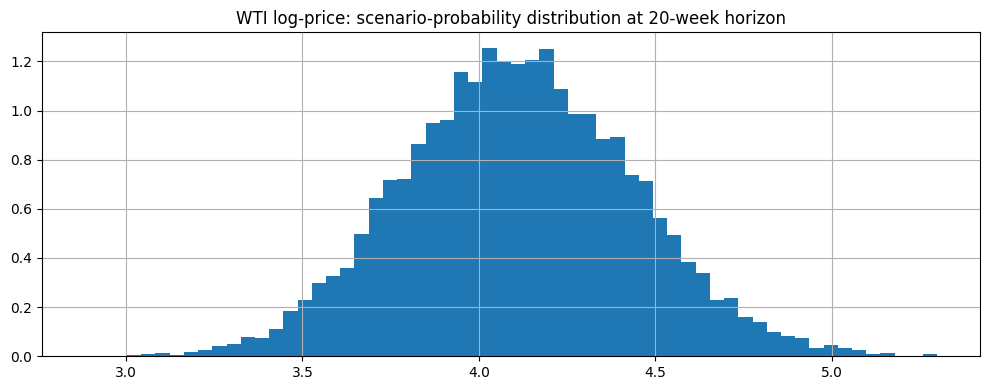

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(x_paths[-1, :], bins=60, density=True)
plt.title("WTI log-price: scenario-probability distribution at 20-week horizon")
plt.grid(True)
plt.tight_layout()
plt.show()

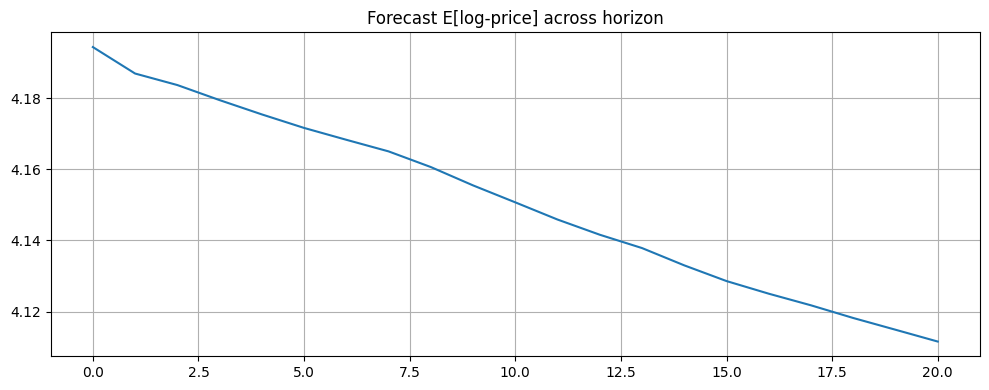

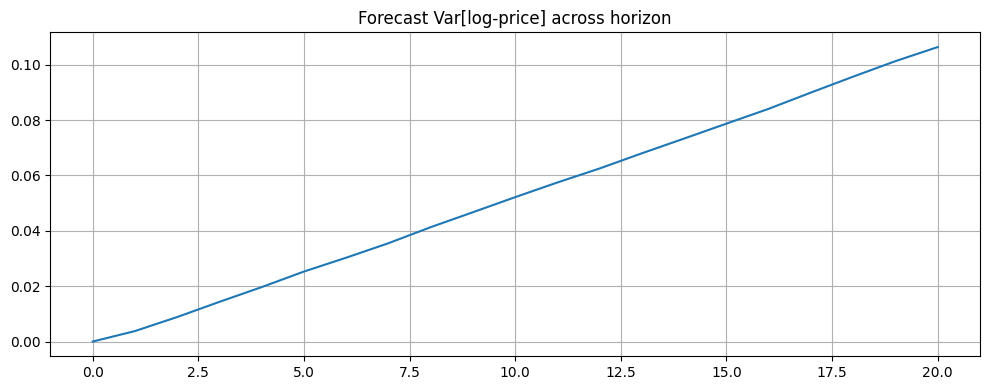

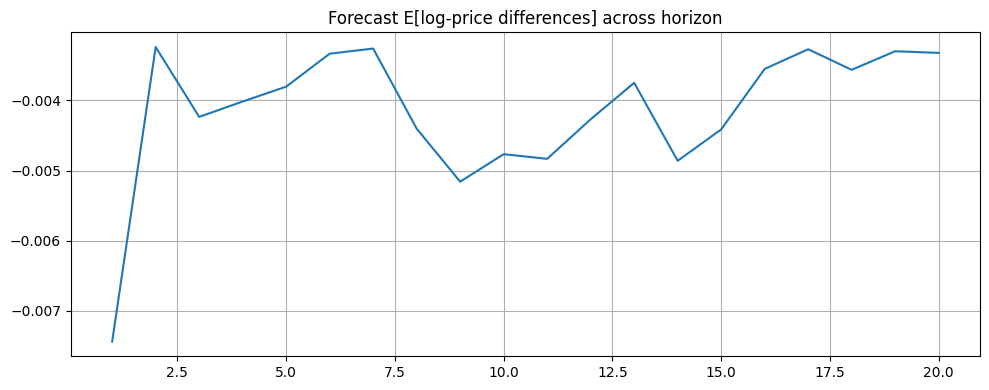

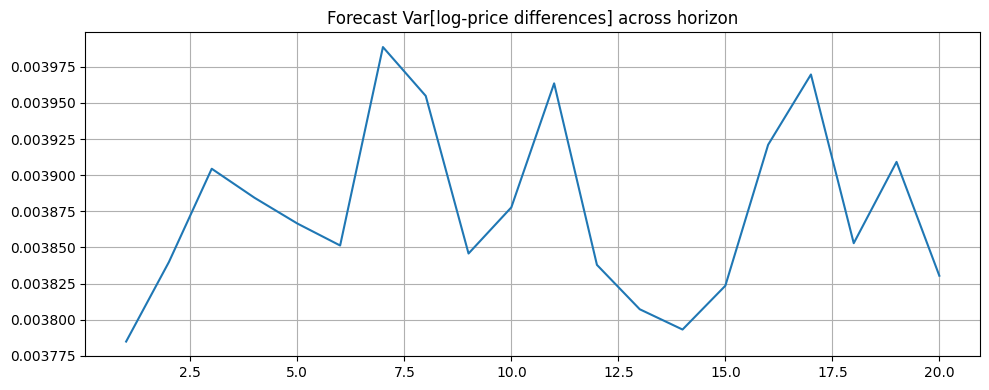

In [ ]:
mean_x = x_paths.mean(axis=1)
var_x  = x_paths.var(axis=1)

# log-diff forecast = r_{t+h}; usa h=1..H (h=0 è 0 per definizione qui)
mean_r = r_paths[1:, :].mean(axis=1)
var_r  = r_paths[1:, :].var(axis=1)

h_grid = np.arange(0, H+1)
h_grid_r = np.arange(1, H+1)

plt.figure(figsize=(10,4))
plt.plot(h_grid, mean_x)
plt.title("Forecast E[log-price] across horizon")
plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(h_grid, var_x)
plt.title("Forecast Var[log-price] across horizon")
plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(h_grid_r, mean_r)
plt.title("Forecast E[log-price differences] across horizon")
plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(h_grid_r, var_r)
plt.title("Forecast Var[log-price differences] across horizon")
plt.grid(True); plt.tight_layout(); plt.show()

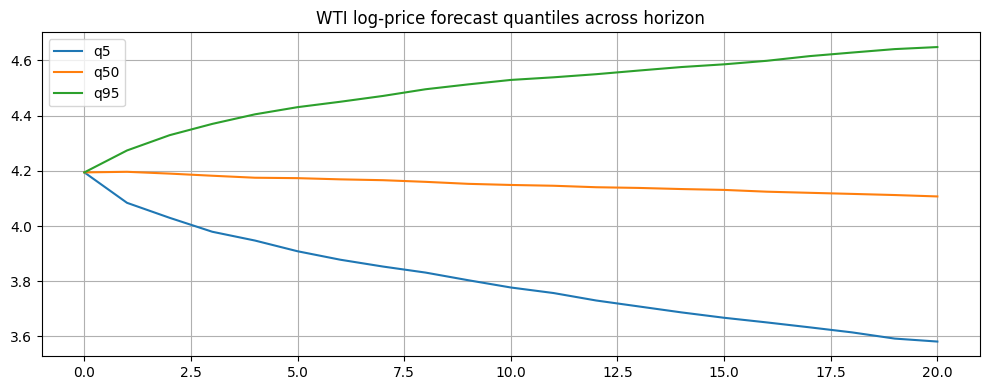

In [ ]:
qs = [0.05, 0.5, 0.95]
q_paths = np.quantile(x_paths, qs, axis=1)   # shape (3, H+1)

plt.figure(figsize=(10,4))
for i,q in enumerate(qs):
    plt.plot(np.arange(0,H+1), q_paths[i,:], label=f"q{int(q*100)}")
plt.title("WTI log-price forecast quantiles across horizon")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
q_paths

array([[4.19434068, 4.08405801, 4.0296881 , 3.97921158, 3.94738731,
        3.90853995, 3.8779349 , 3.85320529, 3.83131421, 3.803624  ,
        3.77725369, 3.75720591, 3.73017889, 3.70862178, 3.68705613,
        3.66758255, 3.65075043, 3.63301427, 3.61464313, 3.59216397,
        3.58140476],
       [4.19434068, 4.19645326, 4.189918  , 4.18220066, 4.17497961,
        4.17346087, 4.16911427, 4.16606806, 4.16006984, 4.15286365,
        4.14879395, 4.14592728, 4.14056502, 4.13802222, 4.13398112,
        4.13086317, 4.12440379, 4.1203459 , 4.1163998 , 4.1122855 ,
        4.10719177],
       [4.19434068, 4.27381443, 4.32921416, 4.37007341, 4.4047179 ,
        4.43072978, 4.45026579, 4.47129897, 4.49556677, 4.51318313,
        4.52934663, 4.53885037, 4.55011729, 4.56335574, 4.57607449,
        4.58590407, 4.5986681 , 4.61555231, 4.62852339, 4.64105706,
        4.64845373]])

<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
  <i>Using a weighted residual bootstrap on the fitted AR(1) model for WTI log-price differences, I generated a scenario–probability forecast of the WTI log-price over a 20-week horizon using 10,000 scenarios. The 20-week-ahead marginal distribution of log-prices is unimodal and approximately bell-shaped, while still reflecting tail risk inherited from the empirical (bootstrapped) innovation distribution.

Forecast uncertainty increases with the horizon: Var[log-price] grows monotonically as returns accumulate over time, which is consistent with the non-stationary behavior of the log-price level observed in the exploratory analysis. By contrast, the forecast variance of log-differences remains broadly stable across horizons, consistent with the (approximate) stationarity of returns.

Conditional mean dynamics are mild. The forecast E[log-price] shows a slight downward drift, driven by the combination of a mildly negative intercept in the AR model for log-differences and the negative most recent observed return used for initialization. This is also visible in the quantile fan chart: the median forecast is nearly flat/slightly decreasing, while the quantile bands widen with horizon. At the 20-week horizon, the 90% scenario–probability interval is [3.581, 4.648] in log-price, with median 4.107, confirming substantial dispersion despite a mild median drift.

Overall, the scenario forecast is coherent with the empirical phenomena discussed earlier: log-prices are not stationary (uncertainty accumulates), while log-differences are closer to stationary (moments stabilize). The weighted bootstrap propagates the historical innovation structure (including volatility bursts and tail behavior) into forward-looking probabilistic forecasts, rather than imposing a Gaussian assumption.</i>
</div>

<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
  <i>Using a weighted residual bootstrap on the fitted AR(1) model for WTI log-price differences, I generated a scenario–probability forecast for the WTI log-price over a 20-week horizon (10,000 scenarios). The 20-week marginal forecast distribution is unimodal and approximately bell-shaped, but it still reflects tail risk because the bootstrap preserves the empirical (non-Gaussian) shape of the innovation distribution rather than imposing normality.

Forecast uncertainty increases with horizon: the forecast variance of log-prices grows monotonically as shocks accumulate through time, which is coherent with the non-stationary / near-unit-root behavior of the log-price level highlighted in the exploratory step. By contrast, the forecast variance of log-differences remains broadly stable across horizons, consistent with log-returns being closer to stationary than levels.

Mean dynamics are mild: the forecast E[log-price] shows a small downward drift, driven by the combination of a slightly negative intercept in the AR model and the most recent return used to initialize the lag structure. This is also visible in the quantile fan chart: the median path is nearly flat / gently decreasing, while the quantile bands widen with horizon. Overall, the results match the empirical features observed earlier: levels accumulate uncertainty, while returns remain approximately stationary, and the weighted bootstrap provides a coherent way to propagate historical innovation structure into forward-looking probabilistic forecasts.</i>
</div>

<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">📝 Task 4: Joint model fit and cointegration</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Fit a VAR(1) model on the joint time series of WTI and BRENT crude oil futures log-prices and NVIDIA stock prices.
- Display the eigenvalues of the fitted matrix $\boldsymbol{b}$. Are there cointegrated relationships? If yes, how many?
- Fit an AR(1) model on the spread between WTI and BRENT crude oil futures log-prices. Plot the related time series and interpret the obtained result based on the error-correction representation.

</p></div></div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Y: DataFrame con colonne ["WTI","BRENT","NVDA"] già in log-price e allineate weekly
Y = logp[["WTI","BRENT","NVDA"]].dropna()

# 1) VAR(1)
var_res = VAR(Y).fit(1)
A1 = var_res.coefs[0]  # (3x3) per VAR(1)

print(var_res.summary())
print("\nA1 (VAR(1) matrix):\n", pd.DataFrame(A1, index=Y.columns, columns=Y.columns))

# 2) Eigenvalues of B (=A1 for VAR(1))
eigvals = np.linalg.eigvals(A1)
print("\nEigenvalues of A1:", eigvals)
print("Moduli:", np.abs(eigvals))

# Heuristic: count eigenvalues "near 1"
thr = 0.98
m_unit = int(np.sum(np.abs(eigvals) > thr))
r_heur = Y.shape[1] - m_unit
print(f"\nHeuristic unit-roots m≈{m_unit} (|λ|>{thr}), implied cointegration rank r≈{r_heur}")

# 3) Johansen test (recommended)
# VAR(1) in livelli <-> VECM with k_ar_diff = 0
jres = coint_johansen(Y, det_order=0, k_ar_diff=0)

trace_stat = jres.lr1
crit_95 = jres.cvt[:, 1]   # colonna 95%

rank_95 = int(np.sum(trace_stat > crit_95))
print("\nJohansen trace stats:", trace_stat)
print("Johansen 95% critical values:", crit_95)
print("Johansen implied cointegration rank at 95%:", rank_95)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Feb, 2026
Time:                     22:58:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -19.1330
Nobs:                     521.000    HQIC:                  -19.1926
Log likelihood:           2803.89    FPE:                4.44697e-09
AIC:                     -19.2310    Det(Omega_mle):     4.34610e-09
--------------------------------------------------------------------
Results for equation WTI
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.041270         0.030897            1.336           0.182
L1.WTI           0.951639         0.050993           18.662           0.000
L1.BRENT         0.037062         0.051963            0.713           0.476
L1.NVD

                            AutoReg Model Results                             
Dep. Variable:                 spread   No. Observations:                  522
Model:                     AutoReg(1)   Log Likelihood                1225.903
Method:               Conditional MLE   S.D. of innovations              0.023
Date:                Sun, 22 Feb 2026   AIC                          -2445.807
Time:                        22:59:25   BIC                          -2433.039
Sample:                    01-11-2013   HQIC                         -2440.806
                         - 12-30-2022                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0096      0.002     -4.986      0.000      -0.013      -0.006
spread.L1      0.8755      0.021     42.099      0.000       0.835       0.916
                                    Roots           

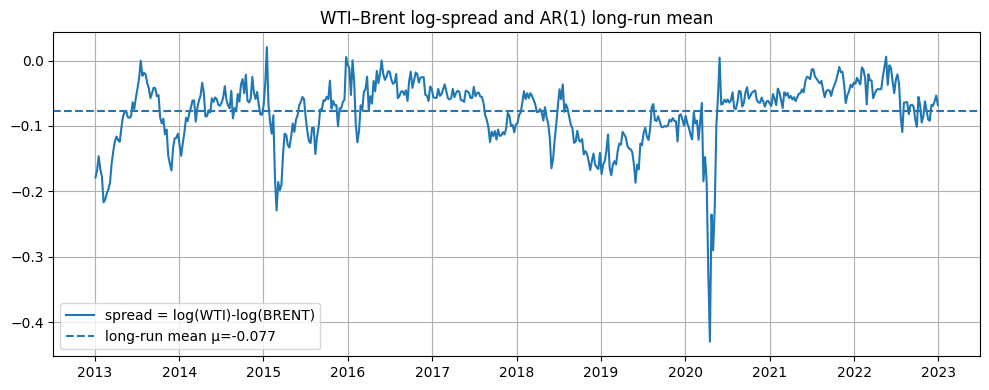

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
import numpy as np
import matplotlib.pyplot as plt

spread = (Y["WTI"] - Y["BRENT"]).dropna()
spread.name = "spread"   # <-- fix

ar_spread = AutoReg(spread, lags=1, trend="c").fit()

alpha = ar_spread.params["const"]
rho   = ar_spread.params["spread.L1"]

mu = alpha / (1 - rho) if abs(1 - rho) > 1e-8 else np.nan
half_life = np.log(0.5) / np.log(rho) if (rho > 0 and rho < 1) else np.nan

print(ar_spread.summary())
print(f"\nSpread AR(1): alpha={alpha:.6f}, rho={rho:.6f}")
print(f"Implied long-run mean mu={mu:.6f}")
print(f"Half-life (weeks) ≈ {half_life:.2f}")

plt.figure(figsize=(10,4))
plt.plot(spread.index, spread.values, label="spread = log(WTI)-log(BRENT)")
plt.axhline(mu, linestyle="--", label=f"long-run mean μ={mu:.3f}")
plt.title("WTI–Brent log-spread and AR(1) long-run mean")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()



```
```

<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
<i>
I fitted a VAR(1) model on the joint log-price vector [log(WTI), log(Brent), log(NVDA)].
The estimated VAR(1) coefficient matrix B has eigenvalues 0.8717 and a complex-conjugate pair
0.9929 ± 0.0051 i, with moduli [0.8717, 0.9929, 0.9929]. The presence of two eigenvalues with modulus
close to one suggests two common stochastic trends (unit-root components) in the 3-dimensional system,
implying an approximate cointegration rank r ≈ 3 − 2 = 1. This interpretation is consistent with the extremely
high residual correlation between WTI and Brent (≈ 0.91), while NVDA is only weakly correlated with the oil complex.

To validate the eigenvalue-based diagnostic, I ran a Johansen cointegration test, which yields trace statistics
[48.53, 15.08, 1.40] against 95% critical values [29.80, 15.49, 3.84], implying a cointegration rank of r = 1
at the 95% level. Economically, this indicates the existence of one stable long-run equilibrium relation linking
(primarily) the two crude oil benchmarks, while NVDA behaves as a separate integrated component not tied to oil
by a stable equilibrium.

I then modeled the WTI–Brent log-spread s_t = log(WTI_t) − log(Brent_t) with an AR(1). The estimated parameters
are alpha = −0.0096 and rho = 0.8755 (highly significant), implying a long-run mean mu = alpha / (1 − rho) ≈ −0.0770.
Since 0 < rho < 1, the spread is mean-reverting, which is direct evidence of cointegration between WTI and Brent.
In error-correction form:

Δs_t = (rho − 1) (s_{t−1} − mu) + ε_t,

so deviations of the spread from its equilibrium level mu are expected to be corrected over time. The implied half-life
is ≈ 5.2 weeks, indicating relatively fast correction of WTI–Brent dislocations, with notable temporary disruptions
during stress episodes (e.g., the large widening around 2020) that nonetheless revert toward the long-run mean.
Overall, the results support a joint dynamics with a shared oil common component plus a stationary relative-value spread,
consistent with an error-correction representation for the two crude benchmarks.
</i>
</div>

<div style="border-left: 4px solid #B5A1CE; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #e2daec; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">📝 Task 5: Model validation</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Fit a linear state-space model with one factor on the joint time series of WTI and BRENT crude oil futures log-prices.
- Plot the time series of the filtered factor via Kalman filter and the realized observational residuals.
- Compare the time series of observational residual with the adjusted spread series; and the time series of the filtered factor with the crude oil futures log-prices. Draw your final conclusions on i) interpretation of the hidden factor and the residual ii) the overall best model to be chosen for the joint dynamics of the examined time series.

**Hint:** See <a style="color:#3c9591" href="../Python/1. Theory/Data Science/47. Linear stochastic models/s_kalman_filter_yield_curve.ipynb">s_kalman_filter_yield_curve</a> for reference.

</p></div></div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Y_oil = Y[["WTI","BRENT"]].dropna()     # log-prices
spread = (Y_oil["WTI"] - Y_oil["BRENT"]).rename("spread")
adj_spread = (spread - mu).rename("adj_spread")   # mu = long-run mean stimato nel task 4

In [ ]:
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor

# 1-factor state-space; factor AR(1); idiosyncratic errors white (error_order=0)
mod = DynamicFactor(Y_oil, k_factors=1, factor_order=1, error_order=0)
res = mod.fit(disp=False)

print(res.summary())

                                   Statespace Model Results                                  
Dep. Variable:                      ['WTI', 'BRENT']   No. Observations:                  522
Model:             DynamicFactor(factors=1, order=1)   Log Likelihood                1332.198
Date:                               Sun, 22 Feb 2026   AIC                          -2654.396
Time:                                       23:12:11   BIC                          -2633.107
Sample:                                   01-04-2013   HQIC                         -2646.058
                                        - 12-30-2022                                         
Covariance Type:                                 opg                                         
Ljung-Box (L1) (Q):          95.83, 375.04   Jarque-Bera (JB):     7120.90, 1281.01
Prob(Q):                        0.00, 0.00   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         1.49, 1.29   Skew:                       0.11, 1

In [ ]:
# --- filtered factor (Kalman filtered) ---
filt_f = res.factors.filtered
if isinstance(filt_f, pd.DataFrame):
    f = filt_f.iloc[:, 0].rename("factor1")
else:
    f = pd.Series(filt_f[0], index=Y_oil.index, name="factor1")

# --- observational residuals (one-step-ahead forecast errors) ---
fe = res.filter_results.forecasts_error   # shape: (k_endog, nobs)
obs_resid = pd.DataFrame(fe.T, index=Y_oil.index, columns=Y_oil.columns)

# Residual spread proxy: difference between residuals
resid_spread = (obs_resid["WTI"] - obs_resid["BRENT"]).rename("resid_spread")

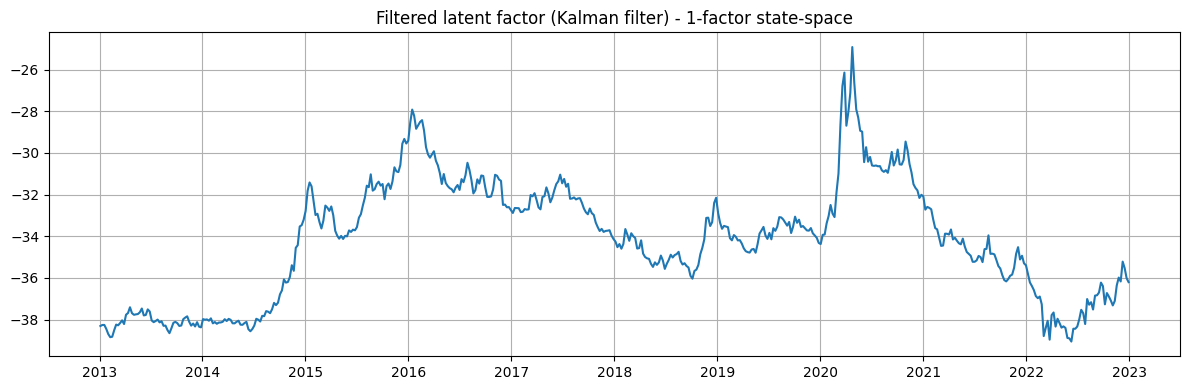

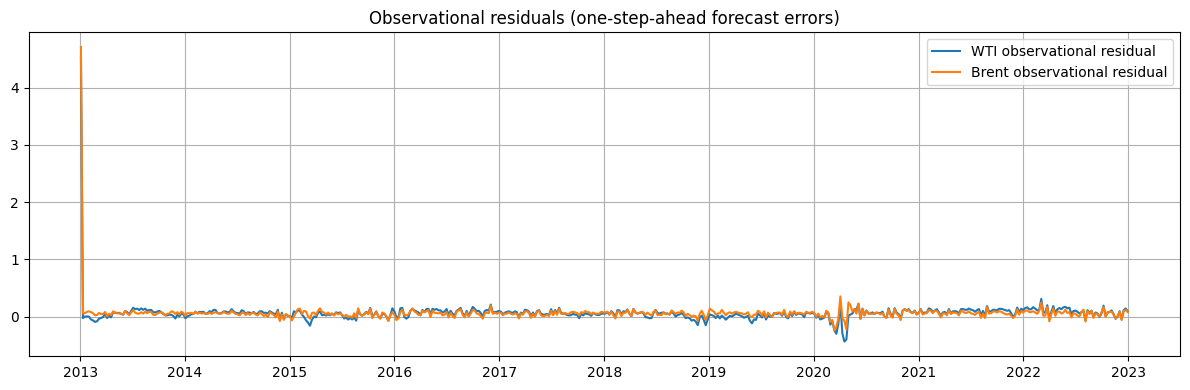

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(f.index, f.values)
plt.title("Filtered latent factor (Kalman filter) - 1-factor state-space")
plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(obs_resid.index, obs_resid["WTI"], label="WTI observational residual")
plt.plot(obs_resid.index, obs_resid["BRENT"], label="Brent observational residual")
plt.title("Observational residuals (one-step-ahead forecast errors)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

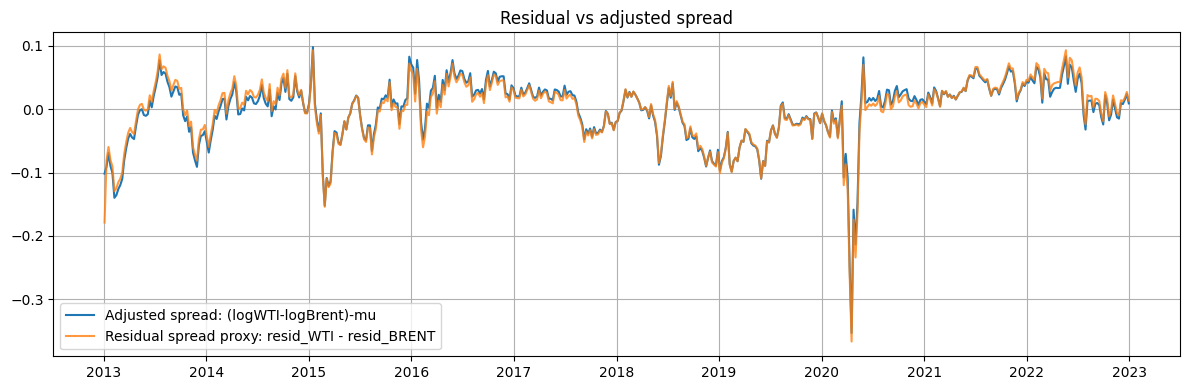

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(adj_spread.index, adj_spread.values, label="Adjusted spread: (logWTI-logBrent)-mu")
plt.plot(resid_spread.index, resid_spread.values, label="Residual spread proxy: resid_WTI - resid_BRENT", alpha=0.8)
plt.title("Residual vs adjusted spread")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

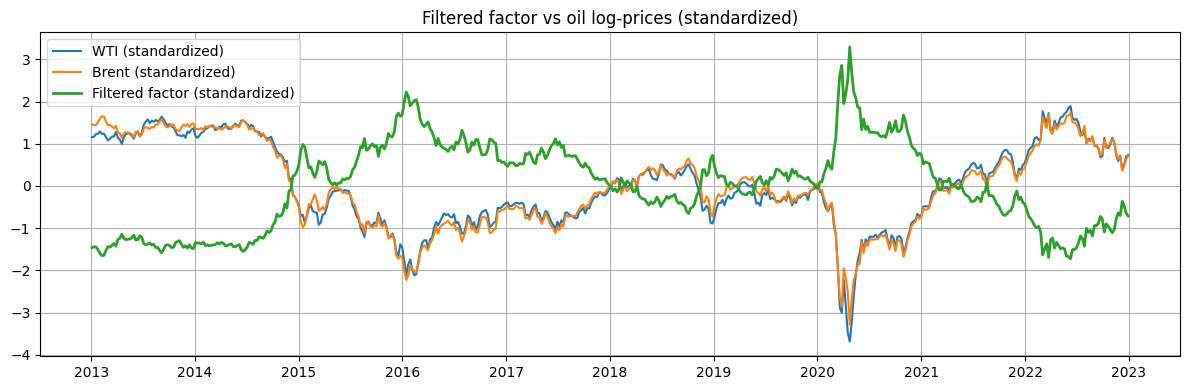

In [ ]:
Z = (Y_oil - Y_oil.mean()) / Y_oil.std()
fZ = (f - f.mean()) / f.std()

plt.figure(figsize=(12,4))
plt.plot(Z.index, Z["WTI"], label="WTI (standardized)")
plt.plot(Z.index, Z["BRENT"], label="Brent (standardized)")
plt.plot(fZ.index, fZ.values, label="Filtered factor (standardized)", linewidth=2)
plt.title("Filtered factor vs oil log-prices (standardized)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

<div style="padding:15px; border-radius:8px;">
  <b>✍️ Explain your insights</b><br><br>
  <i>I fitted a 1-factor linear state-space (dynamic factor) model to the joint log-price vector [WTI, BRENT], with an AR(1) latent factor and white idiosyncratic errors. The estimated factor loadings are almost identical for WTI and Brent (same magnitude), meaning the model is effectively extracting a single common “oil” component that drives both benchmarks. The negative sign of the loadings is just an identification convention (multiplying the factor by −1 would flip the sign without changing the fit or interpretation).

The filtered latent factor closely co-moves with both WTI and Brent (after standardization), supporting the interpretation of the hidden state as a common oil-level driver (shared demand/supply/global risk component). The observational residuals (one-step-ahead forecast errors) remain relatively small most of the time but show bursts during stress episodes (notably around 2020), indicating that idiosyncratic deviations widen under stress.

Comparing series, the difference of observational residuals (resid_WTI − resid_BRENT) tracks very closely the adjusted spread
(
log
⁡
𝑊
𝑇
𝐼
−
log
⁡
𝐵
𝑅
𝐸
𝑁
𝑇
)
−
𝜇
(logWTI−logBRENT)−μ. This supports a clear economic decomposition:



*   Latent factor: the common oil move (shared trend / common shocks).
*   Residual component: a relative-value dislocation (spread deviations) that is largely stationary/mean-reverting and becomes more pronounced in stress.





Model choice conclusion: for interpretability and a clean decomposition common component vs spread, the 1-factor state-space model is excellent and visually validates the cointegration intuition. For explicit modeling of mean-reversion and multi-step joint forecasting under cointegration, a VECM / error-correction specification is often the most “structurally correct” choice. In practice, the best overall description here is: one common stochastic trend + a stationary spread, which both the state-space factor model and the cointegration/error-correction representation are capturing from different angles.</i>
</div>